In [1]:
from matplotlib import cm
from netCDF4 import Dataset 
import numpy as np 
import math
import scipy.stats as stats 
import matplotlib.pyplot as plot
from matplotlib.pyplot import MultipleLocator
from scipy import signal
# import seaborn
import seaborn as sns
import datetime
import calendar
from sklearn import preprocessing

# EP flux divergence

In [2]:
#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/mnt/winds/data2/nnn/ERA5/ur60n10hPa.nc'
filename2 = '/mnt/winds/data2/nnn/ERA5/ub60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

uref = ncin1.variables['uref'] 
uref = (np.array(uref))
ubar = ncin2.variables['ubar'] 
ubar = (np.array(ubar))
print(uref.shape)
print(ubar.shape)

i=0
urp = np.zeros((42,992))
ubp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if uref[j,month[m],i]!=0:
                    urp[i,k] = uref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if uref[j,month[m],i+1]!=0:
                    urp[i,k] = uref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if ubar[j,month[m],i]!=0:
                    ubp[i,k] = ubar[j,month[m],i]
                    k=k+1
            else:
                if ubar[j,month[m],i+1]!=0:
                    ubp[i,k] = ubar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


print(ubp.shape)

#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/mnt/winds/data2/nnn/ERA5/tr60n10hPa.nc'
filename2 = '/mnt/winds/data2/nnn/ERA5/tb60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

tref = ncin1.variables['tref'] 
tref = (np.array(tref))
tbar = ncin2.variables['tbar'] 
tbar = (np.array(tbar))
print(tref.shape)
print(tbar.shape)

i=0
trp = np.zeros((42,992))
tbp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if tref[j,month[m],i]!=0:
                    trp[i,k] = tref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if tref[j,month[m],i+1]!=0:
                    trp[i,k] = tref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if tbar[j,month[m],i]!=0:
                    tbp[i,k] = tbar[j,month[m],i]
                    k=k+1
            else:
                if tbar[j,month[m],i+1]!=0:
                    tbp[i,k] = tbar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


print(tbp.shape)


dmax = 716

ueast = np.zeros((42,dmax))
ratiosl = np.zeros((42,dmax))

onset = np.zeros((42,dmax))
ronset = np.zeros((42,dmax))

onset_id = np.zeros(200)
ronset_id = np.zeros(210)

end = np.zeros((42,dmax))
rend = np.zeros((42,dmax))

end_id = np.zeros(200)
rend_id = np.zeros(210)

ssw = np.zeros((42,dmax))
rssw = np.zeros((42,dmax))

fponset_id = np.zeros(210)

ratio = 0.3

######################################### find out the onset date #######################################

i = 0
while(i < 42):
    j = 0
    while(j < dmax):
        if ubp[i,j] < 0:
            ueast[i,j] = 1 
        if ubp[i,j]/urp[i,j] < ratio:
            ratiosl[i,j] = 1
        j=j+1
    i=i+1

i = 0
n = 0
nn = 0
m = 0
mm = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax):
        if ubp[i,j] < 0 and ueast[i,j-1] == 0:
            onset[i,j] = 1
            onset_id[n] = t
            n=n+1
            #print(date[i][j])
        elif ubp[i,j] > 0 and ueast[i,j-1] == 1:
            end[i,j] = 1
            end_id[m] = t
            m=m+1
        elif j == dmax-1:
            if ueast[i,j] == 1:
                end[i,j] = 1
                end_id[m] = t
                m=m+1
        if ubp[i,j]/urp[i,j] < ratio and ratiosl[i,j-1] == 0: 
            ronset[i,j] = 1
            ronset_id[nn] = t
            nn=nn+1
        elif ubp[i,j]/urp[i,j] > ratio and ratiosl[i,j-1] == 1: 
            rend[i,j] = 1
            rend_id[mm] = t
            mm=mm+1
        elif j == dmax-1:
            if ratiosl[i,j] == 1:
                rend[i,j] = 1
                rend_id[mm] = t
                mm=mm+1
        t=t+1
        j=j+1
    i=i+1


######################################### exclude some events #######################################

n = 1
while(n<210):
    if rend_id[n]-ronset_id[n]<2*4:
        ronset_id[n]=0
        rend_id[n]=0        
    n=n+1


#the interval of the start of an event and the end of the last event should be larger than 10 days
n = 1
while(n<200):
    if (onset_id[n]-end_id[n-1])<10*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1 
n = 2
while(n<200):
    if (onset_id[n]-end_id[n-2])<10*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1

n = 1
while(n<210):
    if (ronset_id[n]-rend_id[n-1])<10*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1 
n = 2
while(n<210):
    if (ronset_id[n]-rend_id[n-2])<10*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1

#there shouldn't be a new event shorter than 20 days
n = 1
while(n<200):
    if onset_id[n]-onset_id[n-1]<20*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1

n = 3
while(n<210):
    if ronset_id[n]-ronset_id[n-3]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1

n = 2
while(n<210):
    if ronset_id[n]-ronset_id[n-2]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1
    
n = 1
while(n<210):
    if ronset_id[n]-ronset_id[n-1]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1  

#the event lasts till the end should be excluded
n = 1
while(n<200):
    if end_id[n]%(dmax-1)==0:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1

n = 1
while(n<210):
    if rend_id[n]%(dmax-1)==0:
        ronset_id[n]=0
        rend_id[n]=0        
    n=n+1

#an event should at least be longer than 2 days
n = 1
while(n<200):
    if end_id[n]-onset_id[n]<2*4:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1


#exclude 3 events
n = 1
while(n<200):
    if onset_id[n]==6380 or onset_id[n]==18525 or onset_id[n]==22145:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1

    
fp=0
tp=0
fn=0
fpb=0

######################################### print out the date #######################################

barplot = np.zeros(6)

i = 0
n = 0
c = 0
while(i < 42):
    j = 1
    while(j < dmax):
        if onset[i,j] == 1:      #ubar<0
            if onset_id[n] == 0: #ubar<0 but there's no SSW
                True
            else:                #there is an SSW
                print(date[i][j])
                
                if date[i][j][5:7] == '11':
                    barplot[0] = barplot[0]+1
                elif date[i][j][5:7] == '12':
                    barplot[1] = barplot[1]+1
                elif date[i][j][5:7] == '01':
                    barplot[2] = barplot[2]+1
                elif date[i][j][5:7] == '02':
                    barplot[3] = barplot[3]+1                    
                elif date[i][j][5:7] == '03':
                    barplot[4] = barplot[4]+1                     
                elif date[i][j][5:7] == '04':
                    barplot[5] = barplot[5]+1                     
                
                if ubp[i,j-2]/urp[i,j-2] < ratio: #find out true positive
                    tp=tp+1
#                if ubp[i,j]/urp[i,j] > ratio: #find out false negative
#                    fn=fn+1                
                c=c+1            #how many SSWs
            n=n+1                #the size of onset_id        
        j=j+1
    i=i+1

print('####################################')

i = 0
nn = 0
cc = 0
while(i < 42):
    j = 1
    while(j < dmax): 
        if ronset[i,j] == 1:      #ubar/uref<0.3
            if ronset_id[nn] == 0: #ubar/uref<0.3 but there's no SSW
                True
            else:
                #print(date[i][j])
                cc=cc+1            #how many rSSWs
            nn=nn+1                #the size of onset_id       
        j=j+1
    i=i+1


    
######################################### mark each day of ssw #######################################
i = 0
n = 0
nn = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax):       
        if t>=onset_id[n] and t<=end_id[n]:
            ssw[i,j] = 1
        if end[i,j]==1:
            n=n+1                #the size of onset_id   
        if t>=ronset_id[nn] and t<=rend_id[nn]:
            rssw[i,j] = 1
        if rend[i,j]==1:
            nn=nn+1                #the size of onset_id  
        t=t+1
        j=j+1
    i=i+1
    
print('####################################')
######################################### find out false positive #######################################
nn = 0
fponset_id=ronset_id
while(nn < 210):
    n = 0
    while(n < 200):
        if onset_id[n]>ronset_id[nn] and onset_id[n]<rend_id[nn]: #exclude onset happen between <0.3 start and end
            fponset_id[nn]=0
        elif abs(onset_id[n]-ronset_id[nn])<40: #exclude 0.3 and onset too far way
            fponset_id[nn]=0
        n=n+1
    nn=nn+1

i = 0
n = 0
nn = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax): 
        if ronset[i,j] == 1: 
            if fponset_id[nn] != 0:      #ubar/uref<0.3
                fp=fp+1
                if ubp[i,j+5]<ubp[i,j]:
                    fpb=fpb+1
            nn=nn+1
        j=j+1
    i=i+1


print('true positive:'+str(tp))
print('total ssws amount:'+str(c))
print('false positive:'+str(fp))
print('false positive but vortex decreasing:'+str(fpb))


filename1 = '/mnt/winds/home/smliu01/3.era-5,ssw_1.2022/ana60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz = ncin1.variables['epz'] 
epz = (np.array(epz))
fawa = ncin1.variables['fawa'] 
fawa = (np.array(fawa))
ubar = ncin1.variables['ubar'] 
ubar = (np.array(ubar))
uref = ncin1.variables['uref'] 
uref = (np.array(uref))


filename1 = '/mnt/winds/home/smliu01/3.era-5,ssw_1.2022/tran60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz_tran = ncin1.variables['epz'] 
epz_tran = (np.array(epz_tran))
fawa_tran = ncin1.variables['fawa'] 
fawa_tran = (np.array(fawa_tran))
ubar_tran = ncin1.variables['ubar'] 
ubar_tran = (np.array(ubar_tran))
uref_tran = ncin1.variables['uref'] 
uref_tran = (np.array(uref_tran))
print(epz.shape)

file = '/mnt/winds/home/smliu01/3.era-5,ssw_1.2022/sea60n.nc'
ncin1 = Dataset(file, 'r', format='NETCDF4') 
fawa_sea = ncin1.variables['fawa'] 
fawa_sea = (np.array(fawa_sea))
ubar_sea = ncin1.variables['ubar'] 
ubar_sea = (np.array(ubar_sea))
uref_sea = ncin1.variables['uref']
uref_sea = (np.array(uref_sea))
epz_sea = ncin1.variables['epz'] 
epz_sea = (np.array(epz_sea))
print(fawa_sea.shape)

fawa_sea_n = np.zeros((97, 124, 12, 43))
ubar_sea_n = np.zeros((97, 124, 12, 43))
uref_sea_n = np.zeros((97, 124, 12, 43))
epz_sea_n = np.zeros((97, 124, 12, 43))

for i in range(43):
    fawa_sea_n[:,:,:,i] = fawa_sea[:,:,:]
    ubar_sea_n[:,:,:,i] = ubar_sea[:,:,:]
    uref_sea_n[:,:,:,i] = uref_sea[:,:,:]
    epz_sea_n[:,:,:,i] = epz_sea[:,:,:]


def Oct_to_May(vv):

    i=0
    vbar = np.zeros((97,42,992))
    days = np.zeros(8)
    dddd = np.zeros((42,992))
    date = dddd.tolist()

    month = [9,10,11,0,1,2,3,4]

    time = ['00','06','12','18']
    months = ['10','11','12','01','02','03','04','05']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<8):
                j=0
                while(j<124):
                    if m<3:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def Nov_to_Mar(vv):

    i=0
    vbar = np.zeros((97,42,604))
    days = np.zeros(5)
    dddd = np.zeros((42,604))
    date = dddd.tolist()

    month = [10,11,0,1,2]

    time = ['00','06','12','18']
    months = ['11','12','01','02','03']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<5):
                j=0
                while(j<124):
                    if m<2:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def sixty_to_sixty(onset_id,dmax,vbar):

    yy=0

    vb = np.zeros((97,22,121*4))

    i=0
    while(i<42):
        for n in range(onset_id.shape[0]):
            if onset_id[n]!=0:
                if int((onset_id[n]+(dmax-1))/(dmax-1))-1==i:
                    kk = onset_id[n]-(dmax-1)*i
                    #print(n,kk)
                    for k in range(int(kk-60*4),int(kk+61*4)):
                        z=0
                        while(z<97):
                            x = int(abs(k-kk+60*4))
                            #print(x)
                            vb[z,yy,x] = vbar[z,i,k]  #################################
                            z=z+1
                    yy = yy+1
        i=i+1
        
    return vb


### Oct to May & -60 to 60

ep = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(epz)),axis=1)
aa = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(fawa)),axis=1)
uu = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(ubar)),axis=1)
ur = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(uref)),axis=1)
print(ep.shape)

ep_eachyr = sixty_to_sixty(onset_id,dmax,Oct_to_May(epz))
aa_eachyr = sixty_to_sixty(onset_id,dmax,Oct_to_May(fawa))
uu_eachyr = sixty_to_sixty(onset_id,dmax,Oct_to_May(ubar))
ur_eachyr = sixty_to_sixty(onset_id,dmax,Oct_to_May(uref))
print(ep_eachyr.shape)

# ep_tran = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(epz_tran)),axis=1)
# aa_tran = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(fawa_tran)),axis=1)
# uu_tran = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(ubar_tran)),axis=1)
# ur_tran = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(uref_tran)),axis=1)
# print('done')

# fw_sea = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(fawa_sea_n)),axis=1)
# ub_sea = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(ubar_sea_n)),axis=1)
# uf_sea = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(uref_sea_n)),axis=1)
# ep_sea = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(epz_sea_n)),axis=1)
# print('done')


uref_eachyr = Oct_to_May(uref)
ubar_eachyr = Oct_to_May(ubar)
fawa_eachyr = Oct_to_May(fawa)
epz_eachyr = Oct_to_May(epz)


print(uref_eachyr.shape)




/tmp/ipykernel_2146409/1952788074.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  uref = (np.array(uref))
/tmp/ipykernel_2146409/1952788074.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ubar = (np.array(ubar))
/tmp/ipykernel_2146409/1952788074.py:93: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https:/

(124, 12, 43)
(124, 12, 43)
(42, 992)
(124, 12, 43)
(124, 12, 43)
(42, 992)
1980/02/29/00
1981/12/04/00
1984/02/23/18
1984/12/31/18
1987/01/22/18
1987/12/08/00
1989/02/21/00
1998/12/15/06
1999/02/25/18
2000/03/19/18
2001/02/11/06
2001/12/30/12
2004/01/04/18
2006/01/21/00
2007/02/24/00
2008/02/21/18
2009/01/24/06
2010/02/09/00
2013/01/06/12
2018/02/11/18
2019/01/19/18
2021/01/05/00
####################################
####################################
true positive:22
total ssws amount:22
false positive:44
false positive but vortex decreasing:39


/tmp/ipykernel_2146409/1952788074.py:460: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  epz = (np.array(epz))
/tmp/ipykernel_2146409/1952788074.py:462: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  fawa = (np.array(fawa))
/tmp/ipykernel_2146409/1952788074.py:464: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https:

(97, 124, 12, 43)
(97, 124, 12)
(97, 484)
(97, 22, 484)
(97, 42, 992)


In [3]:
zdim = 501

height = np.zeros(97)
plev = np.zeros(97)
h1d = np.zeros(zdim)
dz = 500.
hh = 7000.
dz1d = 100000/(zdim-1)
for k in range(97):
    height[k] = k*dz
    plev[k] = 1000*np.exp(-height[k]/hh)
for k in range(zdim):
    h1d[k] = dz1d*k+10000.

print(height[96])
print(h1d[0])

48000.0
10000.0


In [4]:
from scipy.interpolate import interp1d

hhh = np.arange(0,zdim,1)*(100/zdim)+10.

# Create interpolator function
uref_interp = np.zeros((zdim, 42))
for y in range(42):
    # Create interpolator for each year and time step
    f = interp1d(height/1000, np.nanmean(uref_eachyr[:,y,0:5],axis=1), kind='linear', bounds_error=False)
    # Interpolate to new height levels
    uref_interp[:,y] = f(hhh)
    uref_interp[191:,y] = uref_interp[190,y]

fawa_interp = np.zeros((zdim, 42))
for y in range(42):
    f = interp1d(height/1000, np.nanmean(fawa_eachyr[:,y,0:5],axis=1), kind='linear', bounds_error=False)
    fawa_interp[:,y] = f(hhh)
    fawa_interp[188:,y] = fawa_interp[187,y]

ubar_interp = np.zeros((zdim, 42))
for y in range(42):
    f = interp1d(height/1000, np.nanmean(ubar_eachyr[:,y,0:5],axis=1), kind='linear', bounds_error=False)
    ubar_interp[:,y] = f(hhh)
    ubar_interp[191:,y] = ubar_interp[190,y]



/tmp/ipykernel_2146409/4250446107.py:9: RuntimeWarning: Mean of empty slice
  f = interp1d(height/1000, np.nanmean(uref_eachyr[:,y,0:5],axis=1), kind='linear', bounds_error=False)
/tmp/ipykernel_2146409/4250446107.py:16: RuntimeWarning: Mean of empty slice
  f = interp1d(height/1000, np.nanmean(fawa_eachyr[:,y,0:5],axis=1), kind='linear', bounds_error=False)


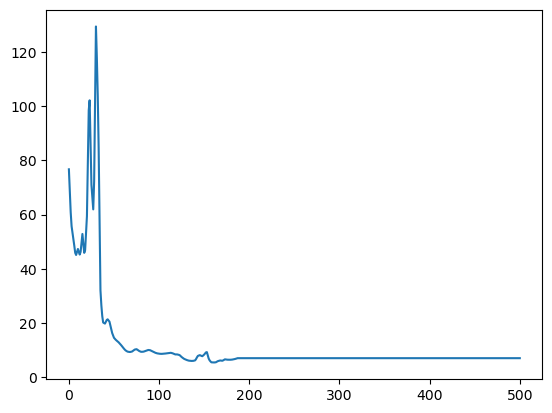

In [5]:
plot.plot(np.mean(fawa_interp[:,:],axis=1))

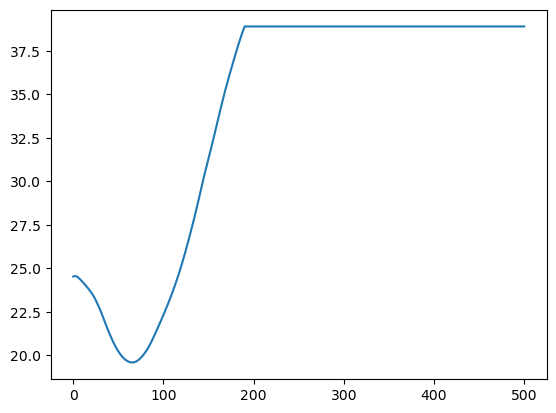

In [6]:
plot.plot(uref_interp[:,10])

In [13]:
fawa_interp.shape

(501, 42)

In [ ]:
# import netCDF4 as nc
# import numpy as np

# # Create a new netCDF file
# ncfile = nc.Dataset('/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/init_'+str(zdim)+'.nc', mode='w', format='NETCDF4')

# # Define dimensions
# time_dim = ncfile.createDimension('height', zdim)
# para_dim = ncfile.createDimension('year', 42)

# # Create variables
# fawa_var = ncfile.createVariable('fawa', np.float32, ('height', 'year'))
# ubar_var = ncfile.createVariable('ubar', np.float32, ('height', 'year'))
# uref_var = ncfile.createVariable('uref', np.float32, ('height', 'year'))

# # Write data to variables
# fawa_var[:] = fawa_interp
# ubar_var[:] = ubar_interp
# uref_var[:] = uref_interp

# # Close the file
# ncfile.close()

In [14]:
import netCDF4 as nc
import numpy as np

# Create a new netCDF file
ncfile = nc.Dataset('/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/init_'+str(zdim-31)+'.nc', mode='w', format='NETCDF4')

# Define dimensions
time_dim = ncfile.createDimension('height', zdim-31)
para_dim = ncfile.createDimension('year', 42)

# Create variables
fawa_var = ncfile.createVariable('fawa', np.float32, ('height', 'year'))
ubar_var = ncfile.createVariable('ubar', np.float32, ('height', 'year'))
uref_var = ncfile.createVariable('uref', np.float32, ('height', 'year'))

# Write data to variables
fawa_var[:] = fawa_interp[31:,:]
ubar_var[:] = ubar_interp[31:,:]
uref_var[:] = uref_interp[31:,:]

# Close the file
ncfile.close()

In [12]:
# import netCDF4 as nc
# import numpy as np

# # Create a new netCDF file
# ncfile = nc.Dataset('/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/init_ranforc.nc', mode='w', format='NETCDF4')

# # Define dimensions
# time_dim = ncfile.createDimension('height', 1001)

# # Create variables
# fawa_var = ncfile.createVariable('fawa', np.float32, ('height'))
# ubar_var = ncfile.createVariable('ubar', np.float32, ('height'))
# uref_var = ncfile.createVariable('uref', np.float32, ('height'))

# # Write data to variables
# fawa_var[:] = np.mean(fawa_interp,axis=1)
# ubar_var[:] = np.mean(ubar_interp,axis=1)
# uref_var[:] = np.mean(uref_interp,axis=1)

# # Close the file
# ncfile.close()

In [ ]:
# import netCDF4 as nc
# import numpy as np

# # Open the init_501.nc file for reading
# ncfile_501 = nc.Dataset('/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/init_501.nc', mode='r')

# # Read the variables (variable names as in the Fortran code: fawa, ubar, uref)
# fawa_501 = ncfile_501.variables['fawa'][:]
# ubar_501 = ncfile_501.variables['ubar'][:]
# uref_501 = ncfile_501.variables['uref'][:]

# print("Loaded init_501.nc shapes:")
# print(f"fawa_501 shape: {fawa_501.shape}")
# print(f"ubar_501 shape: {ubar_501.shape}")
# print(f"uref_501 shape: {uref_501.shape}")

# ncfile_501.close()


Loaded init_501.nc shapes:
fawa_501 shape: (501, 42)
ubar_501 shape: (501, 42)
uref_501 shape: (501, 42)


In [ ]:
# import netCDF4 as nc
# import numpy as np

# # Read the netCDF file to verify the data was written correctly
# ncfile = nc.Dataset('/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/init.nc', mode='r')

# # Read the variables
# fawa_read = ncfile.variables['fawa'][:]
# ubar_read = ncfile.variables['ubar'][:]
# uref_read = ncfile.variables['uref'][:]

# print("Data shapes:")
# print(f"fawa shape: {fawa_read.shape}")
# print(f"ubar shape: {ubar_read.shape}")
# print(f"uref shape: {uref_read.shape}")

# print("\nData verification:")
# print(f"fawa min/max: {np.min(fawa_read):.6f}, {np.max(fawa_read):.6f}")
# print(f"ubar min/max: {np.min(ubar_read):.6f}, {np.max(ubar_read):.6f}")
# print(f"uref min/max: {np.min(uref_read):.6f}, {np.max(uref_read):.6f}")

# ncfile.close()


Data shapes:
fawa shape: (1001, 42)
ubar shape: (1001, 42)
uref shape: (1001, 42)

Data verification:
fawa min/max: 1.205215, 167.175949
ubar min/max: 5.193611, 39.071930
uref min/max: 17.713522, 46.095200


In [5]:
fawa_read.shape

(1001, 42)

In [28]:
print(fawa_read[376,0])

nan
